In [1]:
# Standard scientific Python libraries and plotting/mapping tools
import pandas as pd
import numpy as np
import xarray as xr
from matplotlib import pyplot as plt
import cartopy.feature as cfeature
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sb
import numpy as np


In [2]:
# Load monthly precipitation anomaly and ONI datasets from NetCDF files
precip = xr.open_dataset('precip.mon.anom.nc')
oni = xr.open_dataset('oni.nc')


In [3]:
precip

<xarray.Dataset>
Dimensions:  (lat: 72, lon: 144, time: 934)
Coordinates:
  * lat      (lat) float32 88.75 86.25 83.75 81.25 ... -83.75 -86.25 -88.75
  * lon      (lon) float32 1.25 3.75 6.25 8.75 11.25 ... 351.2 353.8 356.2 358.8
  * time     (time) datetime64[ns] 1948-01-01 1948-02-01 ... 2025-10-01
Data variables:
    precip   (time, lat, lon) float32 ...
Attributes:
    Conventions:               CF-1.2
    title:                     Precipitation Reconstruction (PREC): 2.5x2.5
    history:                   Tue Jun 28 10:57:05 2011: ncea -F -d time,1,76...
    platform:                  Analyses
    institution:               NOAA/PSL
    References:                https://www.psl.noaa.gov/data/gridded/data.pre...
    citation:                  Chen, M., P. Xie, J. E. Janowiak, and P. A. Ar...
    nco_openmp_thread_number:  1
    dataset_title:             Precipitation Reconstruction (PREC)
    data_modified:             2025-11-03

In [4]:
oni

<xarray.Dataset>
Dimensions:  (time: 907)
Coordinates:
  * time     (time) datetime64[ns] 1950-01-01 1950-02-01 ... 2025-07-01
Data variables:
    value    (time) float32 ...

In [5]:
# Trim both datasets to the analysis period 1950–2024,
# excluding partial/unreliable years at the boundaries
def subset_years(data, time_name="time"):
    t = data[time_name]
    # Exclude specific years
    mask_excl = ~t.dt.year.isin([1948, 1949, 2025])
    data2 = data.sel({time_name: t[mask_excl]})
    # Keep 1950-2024 inclusive
    data2 = data2.sel({time_name: slice("1950-01-01", "2024-12-31")})
    return data2

precip = subset_years(precip)
oni = subset_years(oni)


In [6]:
# Compute area-weighted global mean precip anomaly (time series)
precip_vals = precip['precip']
# Weight by cos(latitude) for approximate equal-area weighting on a regular lat/lon grid
weights = np.cos(np.deg2rad(precip['lat']))
weights = weights / weights.mean()  # normalize (not strictly required, but keeps scale intuitive)
precip_global = precip_vals.weighted(weights).mean(dim=("lat", "lon"))

oni_vals = oni['value']

# Align to common times (in case of any missing months)
precip_global, oni_aligned = xr.align(precip_global, oni_vals, join="inner")


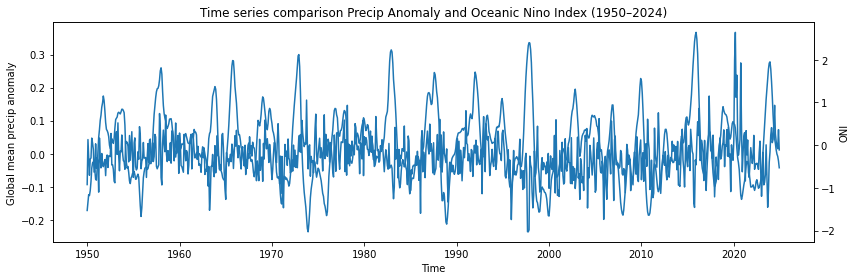

In [7]:
# Plot global mean precip anomaly and ONI on a shared time axis with dual y-axes

fig, ax1 = plt.subplots(figsize=(12, 4))
ax1.plot(precip_global["time"].values, precip_global.values)
ax1.set_ylabel("Global mean precip anomaly")
ax1.set_xlabel("Time")
ax1.set_title("Time series comparison Precip Anomaly and Oceanic Nino Index (1950–2024)")

ax2 = ax1.twinx()
ax2.plot(oni_aligned["time"].values, oni_aligned.values)
ax2.set_ylabel("ONI")

fig.tight_layout()
plt.show()


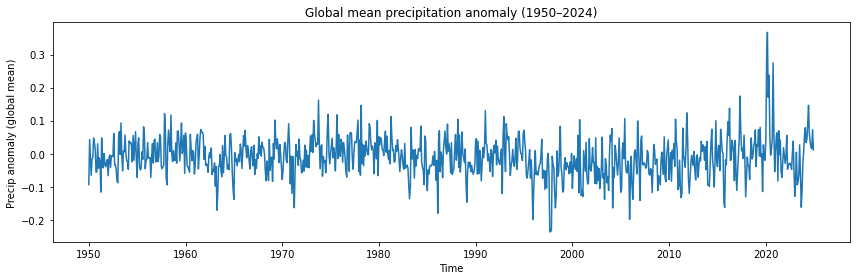

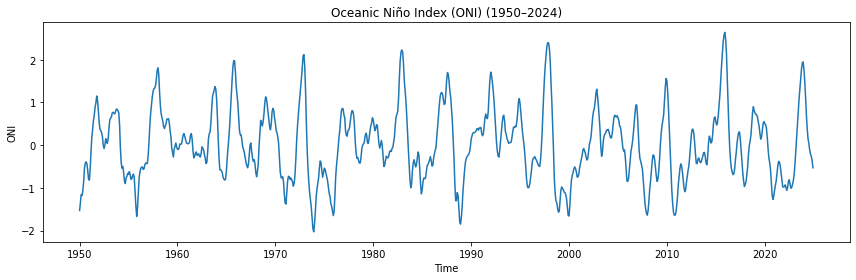

In [8]:
# Plot global mean precip anomaly and ONI as separate time series panels

# Plot 1: Precip anomaly
plt.figure(figsize=(12, 4))
plt.plot(precip_global['time'].values, precip_global)
plt.title('Global mean precipitation anomaly (1950–2024)')
plt.xlabel('Time')
plt.ylabel('Precip anomaly (global mean)')
plt.tight_layout()
plt.show()

# Plot 2: ONI
plt.figure(figsize=(12, 4))
plt.plot(oni['time'].values, oni_vals)
plt.title('Oceánico Niño Index (ONI) (1950–2024)')
plt.xlabel('Time')
plt.ylabel('ONI')
plt.tight_layout()
plt.show()


In [9]:
# Resample monthly data to seasonal means (DJF, MAM, JJA, SON)
# using QS-DEC so each season is anchored to its first month (Dec, Mar, Jun, Sep)

oni_seasonal = oni_vals.resample(time='QS-DEC').mean()
precip_seasonal = precip_vals.resample(time='QS-DEC').mean()

# Separate each season into its own variable for both ONI and precipitation

oni_win = oni_seasonal.sel(time=oni_seasonal['time.month'] == 12)
precip_win = precip_seasonal.sel(time=precip_seasonal['time.month'] == 12)

oni_spr = oni_seasonal.sel(time=oni_seasonal['time.month'] == 3)
precip_spr = precip_seasonal.sel(time=precip_seasonal['time.month'] == 3)

oni_sum = oni_seasonal.sel(time=oni_seasonal['time.month'] == 6)
precip_sum = precip_seasonal.sel(time=precip_seasonal['time.month'] == 6)

oni_fal = oni_seasonal.sel(time=oni_seasonal['time.month'] == 9)
precip_fal = precip_seasonal.sel(time=precip_seasonal['time.month'] == 9)


In [10]:
# Sanity check: confirm the shape and dimensions of the seasonal arrays
# before running correlations

print(oni_win)
print(oni_win.dims)
print(oni_win.shape)


print(precip_win.dims)
print(precip_win.shape)


# Dimensions of seasonal precipitation for DJF:  time: 78, lat: 72, lon: 144
# Dimensions of seasonal SST for DJF: time: 78

# What dimension do precipitation and SST have in common?


<xarray.DataArray 'value' (time: 76)>
array([-1.435     , -0.72      ,  0.57      ,  0.38333336,  0.68      ,
       -0.65333337, -1.1133333 , -0.20666666,  1.7366667 ,  0.61333334,
       -0.08000001,  0.04      , -0.20666666, -0.32666668,  1.        ,
       -0.54999995,  1.4200001 , -0.39666668, -0.6066666 ,  1.0666667 ,
        0.49333334, -1.2966666 , -0.6533333 ,  1.7366667 , -1.8066667 ,
       -0.5833333 , -1.46      ,  0.7333333 ,  0.6333333 ,  0.03333334,
        0.56333333, -0.25666666, -0.02      ,  2.11      , -0.6433333 ,
       -1.0099999 , -0.44000003,  1.2133334 ,  0.82      , -1.6566666 ,
        0.1       ,  0.35999998,  1.6233333 ,  0.08666667,  0.06333333,
        0.92333335, -0.8766667 , -0.45000002,  2.1866667 , -1.4733334 ,
       -1.5733333 , -0.6466667 , -0.14333333,  0.8966667 ,  0.34333333,
        0.6366666 , -0.82      ,  0.6066667 , -1.5866667 , -0.79      ,
        1.4266666 , -1.4       , -0.8733333 , -0.35666665, -0.38333333,
        0.56      ,  2.42 

In [12]:
from scipy import stats

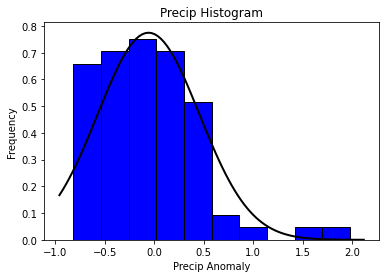

In [13]:
# Plot a histogram of DJF precipitation anomaly at a single SE US grid point
# and overlay a fitted normal distribution to check distributional shape

fig, ax = plt.subplots()

ax.hist(precip_win.sel(lat=26.25, lon=278.75), density=True, color='blue', edgecolor='black')
ax.set_xlabel('Precip Anomaly')
ax.set_ylabel('Frequency')
ax.set_title('Precip Histogram')

# 3. Fit a normal distribution to the data
mu, std = stats.norm.fit(precip_win.sel(lat=26.25, lon=278.75).values)

# 4. Generate x-values for the PDF curve
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)

# 5. Calculate the PDF values
p = stats.norm.pdf(x, mu, std)

# 6. Overlay the PDF curve
ax.plot(x, p, 'k', linewidth=2)


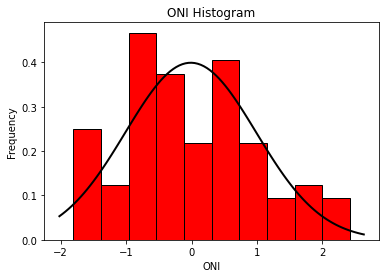

In [14]:
# Same distributional check for DJF ONI values

fig, ax = plt.subplots()

ax.hist(oni_win, density=True, color='red', edgecolor='black')
ax.set_xlabel('ONI')
ax.set_ylabel('Frequency')
ax.set_title('ONI Histogram')

# 3. Fit a normal distribution to the data
mu, std = stats.norm.fit(oni_win.values)

# 4. Generate x-values for the PDF curve
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)

# 5. Calculate the PDF values
p = stats.norm.pdf(x, mu, std)

# 6. Overlay the PDF curve
ax.plot(x, p, 'k', linewidth=2)


In [19]:
# Additional imports needed for correlation map helpers
import matplotlib.ticker as mticker


In [63]:
# Global constants shared by all map-plotting functions
CMAP = 'RdBu_r'          # perceptually uniform diverging colormap
LEVELS = np.linspace(-0.8, 0.8, 17)
SE_EXTENT = [265, 285, 25, 37]

# Compute Pearson r and a two-tailed p-value at every (lat, lon) grid point
# by converting r to a t-statistic and evaluating against the t-distribution
def corr_pval_grid(oni_ts, precip_4d, time_dim='time'):
    """
    Compute Pearson r and two-tailed p-value at every (lat, lon) grid point.
    """
    r_map = xr.corr(oni_ts, precip_4d, dim=time_dim)
    n = precip_4d.sizes[time_dim]
    r_v = r_map.values
    with np.errstate(divide='ignore', invalid='ignore'):
        t_v = r_v * np.sqrt((n - 2) / np.maximum(1 - r_v**2, 1e-12))
    p_v = 2 * stats.t.sf(np.abs(t_v), df=n - 2)
    p_map = xr.DataArray(p_v, coords=r_map.coords, dims=r_map.dims)
    return r_map, p_map

# Estimate effective sample size to account for temporal autocorrelation;
# reduces the apparent degrees of freedom when consecutive values are correlated
def effective_n(x, y):
    """
    Estimate N_eff using lag-1 autocorrelation (Dawdy & Matalas 1964).
    N_eff = N * (1 - r1x*r1y) / (1 + r1x*r1y)
    """
    n = len(x)
    r1x = np.corrcoef(x[:-1], x[1:])[0, 1]
    r1y = np.corrcoef(y[:-1], y[1:])[0, 1]
    n_eff = n * (1 - r1x * r1y) / (1 + r1x * r1y)
    return max(int(n_eff), 3)

# Return Pearson r and a p-value recalculated using N_eff degrees of freedom
# rather than the raw sample size
def corr_pval_neff(x, y):
    """Pearson r and p-value adjusted for autocorrelation (N_eff d.o.f.)."""
    r, _ = stats.pearsonr(x, y)
    n_eff = effective_n(x, y)
    t = r * np.sqrt((n_eff - 2) / max(1 - r**2, 1e-12))
    p = 2 * stats.t.sf(abs(t), df=n_eff - 2)
    return r, p, n_eff

# Reusable map-plotting function: draws filled correlation contours over the
# SE US domain and stipples grid points that are not statistically significant
def plot_corr_map(ax, corr, pval, title, alpha=0.05):
    """
    Filled-contour correlation map.
    Non-significant gridpoints (p >= alpha) are shown as small dots (stippling).
    Uses RdBu_r.
    """
    ax.set_extent(SE_EXTENT, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.6, linestyle=':')
    ax.add_feature(cfeature.STATES,  linewidth=0.6, linestyle=':')

    # Correlation shading
    cf = ax.contourf(
        corr.lon, corr.lat, corr,
        levels=LEVELS, cmap=CMAP, extend='both',
        transform=ccrs.PlateCarree()
    )

    # Stipple non-significant points using scatter (robust across versions)
    # Build meshgrid of lon/lat, then scatter only where p >= alpha
    lon2d, lat2d = np.meshgrid(pval.lon.values, pval.lat.values)
    insig_mask = pval.values >= alpha
    ax.scatter(
        lon2d[insig_mask], lat2d[insig_mask],
        s=0.5, c='dimgray', marker='.', alpha=0.6,
        transform=ccrs.PlateCarree(), zorder=3
    )

    # Suppress top and right axis labels; try both new and legacy cartopy APIs
    gl = ax.gridlines(
        draw_labels=True, linewidth=0.3, color='gray', alpha=0.5,
        #x_inline=False, y_inline=False
    )
    gl.top_labels    = False
    gl.right_labels  = False
    try:
        gl.xlabels_top   = False
        gl.ylabels_right = False
    except AttributeError:
        pass
    gl.xlocator = mticker.FixedLocator(range(-100, -70, 5))
    gl.ylocator = mticker.FixedLocator(range(25,  40,  5))

    ax.set_title(title, fontsize=10)
    return cf


In [64]:
import cartopy.crs as ccrs


/Users/Brad/opt/anaconda3/lib/python3.8/site-packages/scipy/stats/_distn_infrastructure.py:1932: RuntimeWarning: invalid value encountered in less_equal
  cond2 = cond0 & (x <= _a)
/Users/Brad/opt/anaconda3/lib/python3.8/site-packages/scipy/stats/_distn_infrastructure.py:1932: RuntimeWarning: invalid value encountered in less_equal
  cond2 = cond0 & (x <= _a)
/Users/Brad/opt/anaconda3/lib/python3.8/site-packages/scipy/stats/_distn_infrastructure.py:1932: RuntimeWarning: invalid value encountered in less_equal
  cond2 = cond0 & (x <= _a)
/Users/Brad/opt/anaconda3/lib/python3.8/site-packages/scipy/stats/_distn_infrastructure.py:1932: RuntimeWarning: invalid value encountered in less_equal
  cond2 = cond0 & (x <= _a)
<ipython-input-63-162890e823e0>:64: RuntimeWarning: invalid value encountered in greater_equal
  insig_mask = pval.values >= alpha
<ipython-input-66-94e98adbe8d5>:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorre

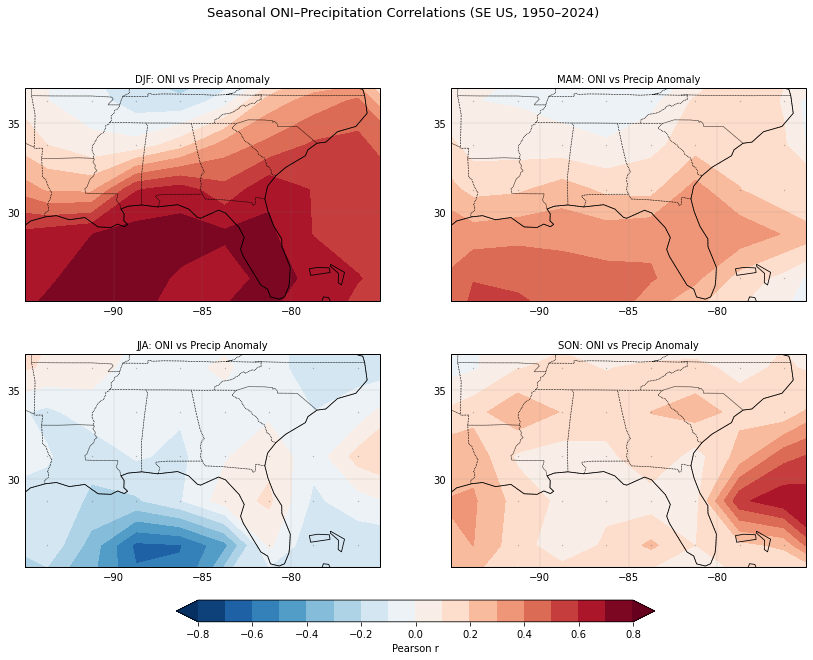

In [66]:
# Compute same-season Pearson r and p-value between ONI and precipitation
# at every SE US grid point for each of the four seasons

seasons = ['DJF', 'MAM', 'JJA', 'SON']
correlations = {}
pvalues = {}

for season in seasons:
    oni_s  = oni_seasonal.sel(time=oni_seasonal['time.season']  == season)
    pre_s  = precip_seasonal.sel(time=precip_seasonal['time.season'] == season)
    r, p   = corr_pval_grid(oni_s, pre_s, time_dim='time')
    correlations[season] = r
    pvalues[season]      = p

# Plot a 2x2 panel of correlation maps, one per season;
# dots indicate regions that are not significant at the 95% level
fig, axes = plt.subplots(
    2, 2, figsize=(14, 10),
    subplot_kw={'projection': ccrs.PlateCarree()}
)
axes = axes.flatten()

for i, season in enumerate(seasons):
    cf = plot_corr_map(
        axes[i], correlations[season], pvalues[season],
        f'{season}: ONI vs Precip Anomaly' #(dots = p≥0.05)
    )

cbar = fig.colorbar(cf, ax=axes, orientation='horizontal',
                    fraction=0.04, pad=0.06, label='Pearson r')
plt.suptitle(
    'Seasonal ONI–Precipitation Correlations (SE US, 1950–2024)\n'
    ,fontsize=13
)
plt.tight_layout()
plt.show()

#'Dots = not significant at 95%'


/Users/Brad/opt/anaconda3/lib/python3.8/site-packages/scipy/stats/_distn_infrastructure.py:1932: RuntimeWarning: invalid value encountered in less_equal
  cond2 = cond0 & (x <= _a)
<ipython-input-53-162890e823e0>:64: RuntimeWarning: invalid value encountered in greater_equal
  insig_mask = pval.values >= alpha
/Users/Brad/opt/anaconda3/lib/python3.8/site-packages/scipy/stats/_distn_infrastructure.py:1932: RuntimeWarning: invalid value encountered in less_equal
  cond2 = cond0 & (x <= _a)
<ipython-input-53-162890e823e0>:64: RuntimeWarning: invalid value encountered in greater_equal
  insig_mask = pval.values >= alpha
/Users/Brad/opt/anaconda3/lib/python3.8/site-packages/scipy/stats/_distn_infrastructure.py:1932: RuntimeWarning: invalid value encountered in less_equal
  cond2 = cond0 & (x <= _a)
<ipython-input-53-162890e823e0>:64: RuntimeWarning: invalid value encountered in greater_equal
  insig_mask = pval.values >= alpha
<ipython-input-56-4a7f0baf0260>:60: UserWarning: This figure inc

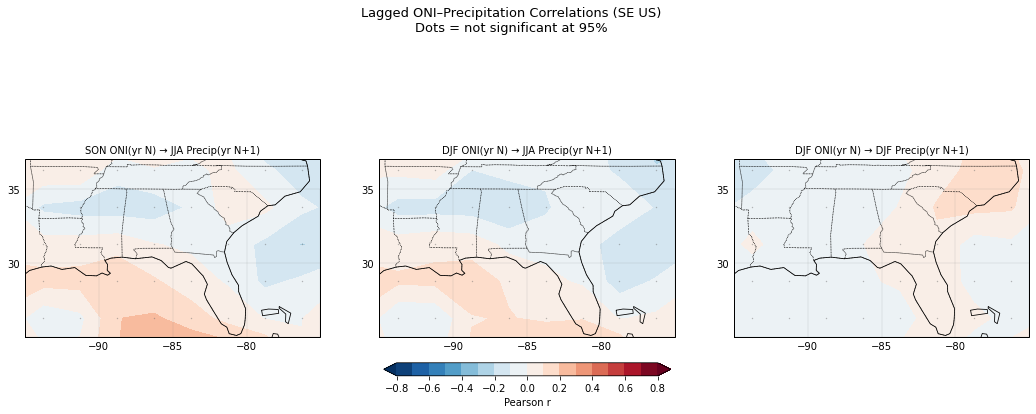

In [56]:
# Compute lagged correlations between ONI in one season and precipitation
# in another season one year later; shift ONI coordinates forward by lag_years
# so that xr.align pairs each ONI value with the following year's precip

def make_lagged_corr(oni_season_str, precip_season_str, lag_years=1):
    """
    Correlate ONI(season, yr N) with precip(season, yr N+lag_years).
    Returns (r_map, p_map).
    """
    oni_s = (
        oni_seasonal
        .where(oni_seasonal.time.dt.season == oni_season_str)
        .groupby('time.year').mean('time')
    )
    pre_s = (
        precip_seasonal
        .where(precip_seasonal.time.dt.season == precip_season_str)
        .groupby('time.year').mean('time')
    )
    oni_lagged = xr.DataArray(
        oni_s.values,
        dims=('year',),
        coords={'year': oni_s['year'].values + lag_years},
    )
    oni_lagged, pre_s = xr.align(oni_lagged, pre_s, join='inner')
    r = xr.corr(pre_s, oni_lagged, dim='year')

    n = pre_s.sizes['year']
    r_v = r.values
    with np.errstate(divide='ignore', invalid='ignore'):
        t_v = r_v * np.sqrt((n - 2) / np.maximum(1 - r_v**2, 1e-12))
    p_v = 2 * stats.t.sf(np.abs(t_v), df=n - 2)
    p = xr.DataArray(p_v, coords=r.coords, dims=r.dims)
    return r, p


# Three lag configurations: SON→JJA+1, DJF→JJA+1, and DJF→DJF+1
lag_configs = [
    ('SON', 'JJA', 1, 'SON ONI(yr N) → JJA Precip(yr N+1)'),
    ('DJF', 'JJA', 1, 'DJF ONI(yr N) → JJA Precip(yr N+1)'),
    ('DJF', 'DJF', 1, 'DJF ONI(yr N) → DJF Precip(yr N+1)'),
]

# Plot the three lagged correlation maps side by side
fig, axes = plt.subplots(
    1, 3, figsize=(18, 6),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

for ax, (oni_s, pre_s, lag, title) in zip(axes, lag_configs):
    r, p = make_lagged_corr(oni_s, pre_s, lag)
    cf   = plot_corr_map(ax, r, p, title)

cbar = fig.colorbar(cf, ax=axes, orientation='horizontal',
                    fraction=0.04, pad=0.08, label='Pearson r')
plt.suptitle(
    'Lagged ONI–Precipitation Correlations (SE US)\nDots = not significant at 95%',
    fontsize=13
)
plt.tight_layout()
plt.show()


In [57]:
import statsmodels.api as sm


=== N_eff Correction ===
  Actual N        : 75
  N_eff           : 75
  Pearson r       : -0.046
  p (standard)    : 0.6930
  p (N_eff adj.)  : 0.6930
  Note: OLS summary uses standard N; use N_eff p above for inference.

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                 -0.012
Method:                 Least Squares   F-statistic:                    0.1571
Date:                Wed, 27 May 2026   Prob (F-statistic):              0.693
Time:                        14:06:55   Log-Likelihood:                -44.308
No. Observations:                  75   AIC:                             92.62
Df Residuals:                      73   BIC:                             97.25
Df Model:                           1                                         
Covariance Type:            nonrobust                             

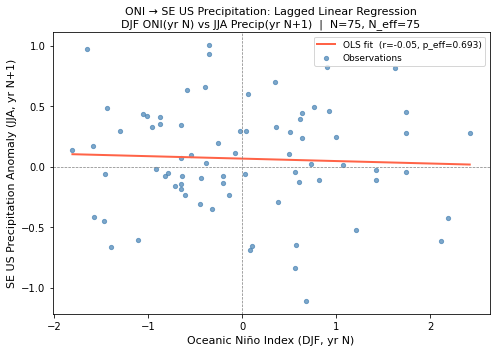

In [58]:
# Fit a univariate OLS regression of SE US summer (JJA) precipitation anomaly
# on the preceding winter (DJF) ONI, then report both standard and
# autocorrelation-corrected (N_eff) significance statistics

lat_min, lat_max    = 24, 38
lon_min_360, lon_max_360 = 265, 285

# Rebuild lagged series
oni_djf_ts = (
    oni_seasonal
    .where(oni_seasonal.time.dt.season == 'DJF')
    .groupby('time.year').mean('time')
)
precip_jja_ts = (
    precip_seasonal
    .where(precip_seasonal.time.dt.season == 'JJA')
    .groupby('time.year').mean('time')
)

# Shift ONI year index forward by 1 so it aligns with the following year's JJA precip
oni_lag_djf = xr.DataArray(
    oni_djf_ts.values,
    dims=('year',),
    coords={'year': oni_djf_ts['year'].values + 1},
    name='oni_djf_lag1'
)
oni_lag_djf, precip_jja_ts = xr.align(oni_lag_djf, precip_jja_ts, join='inner')

# Spatially average precipitation over the SE US bounding box
lat_desc = precip_jja_ts.lat.values[0] > precip_jja_ts.lat.values[-1]
lat_slice = slice(lat_max, lat_min) if lat_desc else slice(lat_min, lat_max)
precip_se_ts = precip_jja_ts.sel(
    lat=lat_slice, lon=slice(lon_min_360, lon_max_360)
).mean(('lat', 'lon'))

x_reg = oni_lag_djf.values
y_reg = precip_se_ts.values
mask  = np.isfinite(x_reg) & np.isfinite(y_reg)
x_reg, y_reg = x_reg[mask], y_reg[mask]

# OLS
x2  = sm.add_constant(x_reg)
mod = sm.OLS(y_reg, x2).fit()
y_pred = mod.fittedvalues

# Print N_eff-corrected statistics alongside the standard OLS summary;
# N_eff accounts for the reduced degrees of freedom caused by autocorrelation
r_val, p_neff, n_eff = corr_pval_neff(x_reg, y_reg)
print('=== N_eff Correction ===')
print(f'  Actual N        : {len(x_reg)}')
print(f'  N_eff           : {n_eff}')
print(f'  Pearson r       : {r_val:.3f}')
print(f'  p (standard)    : {stats.pearsonr(x_reg, y_reg)[1]:.4f}')
print(f'  p (N_eff adj.)  : {p_neff:.4f}')
print(f'  Note: OLS summary uses standard N; use N_eff p above for inference.\n')
print(mod.summary())

# Scatter plot of observations with the OLS regression line overlaid
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(x_reg, y_reg, color='steelblue', s=18, alpha=0.7, label='Observations')
order = np.argsort(x_reg)
ax.plot(x_reg[order], y_pred[order], color='tomato', linewidth=2,
        label=f'OLS fit  (r={r_val:.2f}, p_eff={p_neff:.3f})')
ax.axhline(0, color='gray', linewidth=0.7, linestyle='--')
ax.axvline(0, color='gray', linewidth=0.7, linestyle='--')

ax.set_xlabel('Oceanic Niño Index (DJF, yr N)', fontsize=11)
ax.set_ylabel('SE US Precipitation Anomaly (JJA, yr N+1)', fontsize=11)
ax.set_title(
    f'ONI → SE US Precipitation: Lagged Linear Regression\n'
    f'DJF ONI(yr N) vs JJA Precip(yr N+1)  |  N={len(x_reg)}, N_eff={n_eff}',
    fontsize=11
)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()
